# Photovoltaics

In [ ]:
from enn554.constants import h,c, eV2J, electron_charge, kB
from enn554.pv import SimpleEquivalentCircuit as simple_pv
from enn554.pv import SeriesParallelEquivalentCircuit as spc
from enn554.pv import DeSotoModel as dsm
from enn554.pv import StringModel as sm
import pvlib
import matplotlib.pyplot as plt
import numpy as np

## Semiconductor basics

In [ ]:
Eg_eV = 1.12
Eg_J = Eg_eV*eV2J
λ_max = h*c/Eg_J
ν_min = c/λ_max
print(f"λ_ma = {λ_max/1e-6:.2f}μm, ν_min = {ν_min:.2e}")

In [ ]:
am15 = pvlib.spectrum.get_reference_spectra(standard="ASTM G173-03")
wavelength_meters = am15.index*1e-9
am15['Energy (J)'] = h*c/wavelength_meters
am15['Energy (eV)'] = am15['Energy (J)']/eV2J
am15['Fraction Wasted'] = np.clip(am15['Energy (eV)'] - Eg_eV,a_min=0,a_max=np.inf)/am15['Energy (eV)']
ax = am15.plot(y=['Energy (eV)'],legend=False,ylabel='Energy (eV)',xlabel='Wavelength (nm)')
ax.axhline(1.11,ls=':',color='red',label='Eg')

In [ ]:
fig,ax = plt.subplots(figsize=(10,5))
ax.plot(am15.index,am15['global'],label='AM1.5')
ax.set_ylabel(r'Spectral Global Irradiance $\frac{W}{m^2\cdot nm}$')
useable_spectral_GHI = am15['global']*(1.0-am15['Fraction Wasted'])
ax.fill_between(am15.index,am15['global'],useable_spectral_GHI,where=(am15['Energy (eV)']>=Eg_eV),color='red',alpha=0.25,label=r'Lost as heat ($h\nu > Eg$)')
ax.fill_between(am15.index,useable_spectral_GHI,0,where=(am15['Energy (eV)']>=Eg_eV),color='green',alpha=0.25,label='Useable fraction')
ax.fill_between(am15.index,useable_spectral_GHI,0,where=(am15['Energy (eV)']<Eg_eV),color='black',alpha=0.25,label=r'Photon energy too low ($h\nu<E_G$)')
ax.legend()


In [ ]:
total = useable_GHI = np.trapezoid(y=am15['global'],x=am15.index)
useable_GHI = np.trapezoid(y=am15['global']*(am15['Energy (eV)']>=Eg_eV)*(1-am15['Fraction Wasted']),
                           x=am15.index)
too_low_energy = np.trapezoid(y=am15['global']*(am15['Energy (eV)']<Eg_eV),
                              x=am15.index)
too_high_energy = np.trapezoid(y=am15['global']*(am15['Energy (eV)']>=Eg_eV)*am15['Fraction Wasted'],
                               x=am15.index)
print(f'Useable energy: {useable_GHI/total*100:.1f}%')
print(f'Photon energy (hv) too high: {too_high_energy/total*100:.1f}%')
print(f'Photon energy (hv) too low: {too_low_energy/total*100:.1f}%')

Numbers are slightly different than [1], probably becasue of some differences in the AM1.5 Spectrum.

## Diode


In [ ]:
I0,Isc = 1e-12*150,40e-3*150
model = simple_pv(I0,Isc=Isc)
model.set_irradiance(1000)
ax = model.plot_iv(mplkwds={'label':'1 sun (1000 W/m2)'})
model.set_irradiance(500)
model.plot_iv(ax=ax,mplkwds={'label':'0.5 suns (500 W/m2)'})
ax.legend()

In [ ]:
model.set_irradiance(1000)
ax2 = model.plot_power(mplkwds={'ls':'-','label':'Power for 1 sun'})
model.set_irradiance(500)
ax2 = model.plot_power(ax=ax2,mplkwds={'ls':'-','label':'Power for 0.5 sun'})
ax2.legend()

### Series parallel circuit

In [ ]:
Rp,Rs = 1, 0.0
Isc = 6.0

fig,ax = plt.subplots()
model = simple_pv(I0,Isc=Isc)
model2 = spc(I0,Rp,Rs,Isc=Isc)
model.plot_iv(ax=ax,mplkwds={'label':'Simple'})
model2.plot_iv(ax=ax,mplkwds={'ls':'--','color':'red','label':fr'Rp={Rp:.1f},Rs={Rs:.3f}'})
ax.legend()

Testing the more complex model

In [ ]:
Rp,Rs = 1, 0.05
Isc = 6.0

fig,ax = plt.subplots()
model = simple_pv(I0,Isc=Isc)
model2 = spc(I0,Rp,Rs,Isc=Isc)
model.plot_iv(ax=ax,mplkwds={'label':'Simple'})
model2.plot_iv(ax=ax,mplkwds={'ls':'--','color':'red','label':fr'Rp={Rp:.1f},Rs={Rs:.3f}'})
ax.legend()

### Test De Soto functionality
Using Fig. 6 of [2]

In [ ]:
Isc_ref, Voc_ref = 4.37,42.93
Imp_ref, Vmp_ref = 3.96, 33.68
model = dsm(Ns=72,Isc_ref=Isc_ref,Voc_ref=Voc_ref,Imp_ref=Imp_ref,Vmp_ref=Vmp_ref,delta_Isc=0.00175,delta_Voc=-0.15237)

In [ ]:
def place_annotation(model,ax,x_ann,G,T_C):
    V, I, _ = model.iv_curve(G, T_C)
    y_ann = float(np.interp(x_ann, V, I))
    ax.text(x_ann, y_ann, f"T={T_C:.0f}°C, G={G:.0f} W/m²",fontsize=10, va='bottom')

In [ ]:
ax = model.plot_power_curve(G=1000,T_C=25,mplkwds={'color':'blue'})
vmp,imp,pmp = model.mpp(G=1000,T_C=25)
ax.plot(vmp,pmp,'r*',markersize=10,label='Maximum Power')
ax.plot([vmp,vmp],[0,pmp],'r:',alpha=0.25)
ax.set_ylim((0,150))
ax.get_legend().remove()
ax.set_ylabel('Power (A)',color='blue')
ax.tick_params(axis='y', colors='blue')
ax.spines['right'].set_color('blue')

In [ ]:
ax = model.plot_power_curve(G=1000,T_C=25,mplkwds={'color':'blue'})
vmp,imp,pmp = model.mpp(G=1000,T_C=25)
ax.plot(vmp,pmp,'r*',markersize=10,label='Maximum Power')
ax.plot([vmp,vmp],[0,pmp],'r:',alpha=0.25)
ax.set_ylim((0,150))
ax.set_xlim((0,50))
ax.get_legend().remove()
ax.set_ylabel('Power (A)',color='blue')
ax.tick_params(axis='y', colors='blue')
ax.spines['right'].set_color('blue')

ax2 = ax.twinx()
model.plot_iv(ax=ax2,G=1000,T_C=25,mplkwds={'ls':'--','color':'green'})
ax2.get_legend().remove()
ax2.set_ylim((0,8))
ax2.plot(vmp,imp,'r.',markersize=10,label='MPP')
ax2.set_ylabel('Current (A)',color='green')
ax2.tick_params(axis='y', colors='green')
ax2.spines['right'].set_color('green')
ax2.legend(['I-V curve','Maximum Power Point'],loc='upper left')

ax2.axhline(imp,ls=':',color='green',xmin=vmp/50.0)
ax.legend(['Power curve', 'Max Power'],loc=[0.01,0.7])
ax2.text(46, imp, r"$I_{MPP}$",fontsize=12, va='bottom',color='green')
ax2.text(vmp, 0.5, r"$V_{MPP}$",fontsize=12, va='top',color='red',alpha=0.5)
ax2.fill_between([0,vmp],[imp,imp],alpha=0.15,color='green')
# model.plot_power_curve(ax=ax,G=500,T_C=30)

ax2.axhline(Isc_ref,ls=':',color='gray',xmax=Voc_ref/50.0)
ax2.axvline(Voc_ref,ls=':',color='gray',ymax=Isc_ref/8)
ax2.plot(Voc_ref,Isc_ref,'.',color='grey',markersize=5)
ax2.fill_between([vmp,Voc_ref],[Isc_ref,Isc_ref],
                 alpha=0.1,color='black')
ax2.fill_between([0,vmp],y1=[Isc_ref,Isc_ref],y2=[imp,imp],
                 alpha=0.1,color='black')

In [ ]:
fig,ax = plt.subplots(ncols=2,figsize=(13,5))
x_ann = 8
MPP = []
for G, T_C in [(1000, 25.0), (696, 47.0), (465.7, 32.2)]:
    model.plot_iv(ax=ax[0],G=G,T_C=T_C)
    place_annotation(model,ax[0],x_ann,G=G,T_C=T_C)
    model.plot_power_curve(ax=ax[1],G=G,T_C=T_C)
    MPP.append(model.mpp(G,T_C))

ax[0].set_xlim((0,50))
ax[0].set_ylim((0,5))
ax[0].get_legend().remove()

MPPx = [m[0] for m in MPP]
MPPy = [m[2] for m in MPP]
line, = ax[1].plot(MPPx,MPPy,color='gray',ls=':',marker='*',label='MPP',alpha=0.5)
ax[1].legend(handles=[line],labels=['MPP'])


In [ ]:
ax = model.plot_iv(G=1000,T_C=0.0)
model.plot_iv(ax=ax,G=1000,T_C=25.0, mplkwds={'label':f"T=25C, G=1000 W/m2 (STC)"})
model.plot_iv(ax=ax,G=1000,T_C=40.0)
model.plot_iv(ax=ax,G=1000,T_C=50.0)
model.plot_iv(ax=ax,G=1000,T_C=70.0)
ax.set_xlim((0,50))
ax.set_ylim((0,5))

In [ ]:
ax = model.plot_iv()
place_annotation(model,ax=ax,x_ann=x_ann,G=1000,T_C=25)
conditions = [(800,25),(600,25),(400,25),(200,25)]
x_ann = 8.0
for G, T_C in conditions:
    model.plot_iv(ax=ax,G=G,T_C=T_C)
    place_annotation(model,ax=ax,x_ann=x_ann,G=G,T_C=T_C)

ax.set_xlim((0,50))
ax.set_ylim((0,5))
ax.get_legend().remove()

### Example 5.4
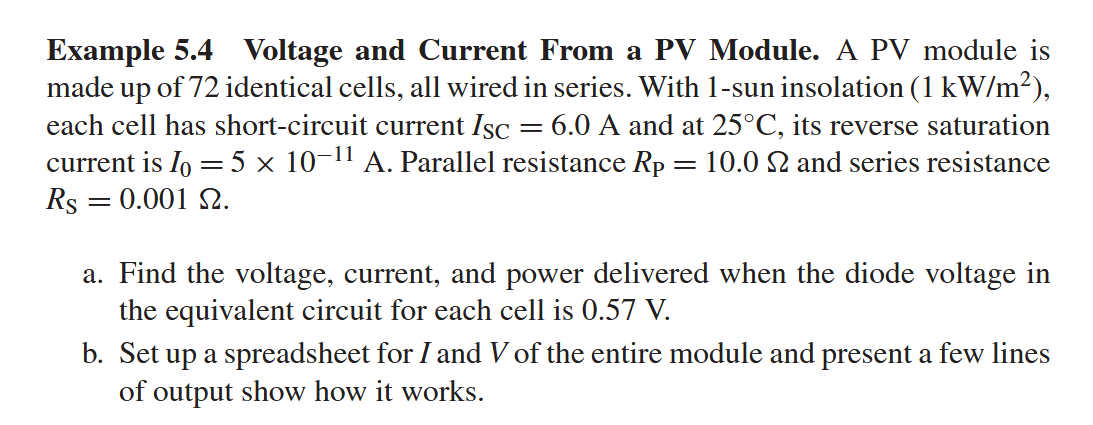

In [ ]:
n_cells = 72
module = spc(5e-11,Rsh=10.0,Rs=0.001,Isc=6.0,T=25+273.15,Ns=n_cells)

(a)

In [ ]:
# V = n_cells*module.voltage(0.57)
I = module.current(Vd=0.57)
V = module.voltage(I=I)
Power= I*V
print(f"V={V:.1f} V, I={I:.2f} A, P={Power:.2f} W")

(b)

In [ ]:
v = np.linspace(0,module.Voc,1000)
i = np.array([module.current(V=vv) for vv in v])

fig,ax = plt.subplots()
ax.plot(v,i,label="I-V curve")
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Current (A)')

ax2 = ax.twinx()
ax2.plot(v,i*v,label='Power',color='red')
ax2.tick_params(axis='y', colors='red')
ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red')
ax2.set_ylabel('Power (W)')

### Shading
In the above, Lets shade one module completely and examine the change in the I-V and power behaviour. 

In [ ]:
def find_mpp(V,I):
    P = V*I
    idx = np.nanargmax(P)
    return V[idx],I[idx],P[idx]

In [ ]:
cell = spc(5e-11,Rsh=10.0,Rs=0.001,Isc=0.5*6.0,T=25+273.15,Ns=1.0)
even_soiling = spc(5e-11,Rsh=10.0,Rs=0.001,Isc=0.9*6.0,T=25+273.15,Ns=n_cells)
v_mpp_full,i_mpp_full,p_mpp_full = find_mpp(v,i)

# soiling
VSH_soil = np.array([even_soiling.voltage(I=ii) for ii in i])

# full shading (one cell)
VSH = v - v/module.Ns - i*module.Rsh
VSH[VSH<0] = np.nan

VSH_2 = v - v/module.Ns - 2*i*module.Rsh
VSH_2[VSH_2<0] = np.nan

# 50% shading
Isc = module.current(Vd=0)
V_cell_50 = np.array([cell.voltage(I=ii) for ii in i]) # cell voltage of the shaded cell
VSH_50 = (module.Ns-1)/module.Ns*v # voltage of the non-shaded cells
VSH_50[i<=Isc/2] += V_cell_50[i<=Isc/2.0]
VSH_50[i>=Isc/2.0] -= v[i>=Isc/2.0]/module.Ns + (i[i>=Isc/2.0]-Isc/2.0)*module.Rsh
VSH_50[VSH_50<0] = np.nan

v_mpp_soil,i_mpp_soil,p_mpp_soil = find_mpp(VSH_soil,i)
v_mpp_shade,i_mpp_shade,p_mpp_shade = find_mpp(VSH,i)
v_mpp_shade_2,i_mpp_shade_2,p_mpp_shade_2 = find_mpp(VSH_2,i)
v_mpp_shade_50,i_mpp_shade_50,p_mpp_shade_50 = find_mpp(VSH_50,i)

fig,ax = plt.subplots()
ax.plot(v,i,label="All cells under full sun")
ax.plot(v_mpp_full,i_mpp_full,'r*',markersize=10)
ax.text(v_mpp_full+0.2, i_mpp_full+0.2, fr"MPP ({p_mpp_full:.0f}W)",fontsize=10, va='bottom',ha='left')
ax.text(20, 6, fr"Full sun",fontsize=10, va='bottom',ha='left')

ax.plot(VSH_soil,i,label="10% soiling")
ax.plot(v_mpp_soil,i_mpp_soil,'r*',markersize=10)
ax.text(v_mpp_soil+0.2, i_mpp_soil+0.1, fr"MPP ({p_mpp_soil:.0f}W)",fontsize=10, va='bottom',ha='left')
ax.text(20, 5.4, fr"10% soiling",fontsize=10, va='bottom',ha='left')

ax.plot(VSH_50,i,label="One cell 50% shaded")
ax.plot(v_mpp_shade_50,i_mpp_shade_50,'r*',markersize=10)
ax.text(v_mpp_shade_50+1.5, i_mpp_shade_50+0.3, fr"MPP ({p_mpp_shade_50:.0f}W)",fontsize=10, va='bottom',ha='center')
ax.text(25,5.25, fr"One cell 50% shaded",fontsize=10, va='top',ha='center',rotation=-25)

ax.plot(VSH,i,label="One cell completely shaded")
ax.plot(v_mpp_shade,i_mpp_shade,'r*',markersize=10)
ax.text(v_mpp_shade+0.2, i_mpp_shade+0.2, fr"MPP ({p_mpp_shade:.0f}W)",fontsize=10, va='bottom',ha='left')
ax.text(12,2.7, fr"One cell 100% shaded",fontsize=10, va='bottom',ha='center',rotation=-26)

ax.plot(VSH_2,i,label="Two cells completely shaded")
ax.plot(v_mpp_shade_2,i_mpp_shade_2,'r*',markersize=10)
ax.text(v_mpp_shade+0.2, i_mpp_shade_2+0.1, fr"MPP ({p_mpp_shade_2:.0f}W)",fontsize=10, va='bottom',ha='left')
ax.text(12,1.35, fr"Two cells 100% shaded",fontsize=10, va='bottom',ha='center',rotation=-15)

ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Current (A)')
ax.set_xlim((0,50))
ax.set_ylim((0,7))

# ax.grid('on')
# ax.legend(bbox_to_anchor=(1.6, 0),loc='lower right', borderaxespad=0.)

## Shading with diodes

In [ ]:
Isc_ref, Voc_ref = 4.37,42.93
Imp_ref, Vmp_ref = 3.96, 33.68
n_diodes = 12
G,temp_celsius = [1000]*n_diodes,40.0
G[-1] = 0.0
model = dsm(Ns=72,Isc_ref=Isc_ref,Voc_ref=Voc_ref,Imp_ref=Imp_ref,Vmp_ref=Vmp_ref,delta_Isc=0.00175,delta_Voc=-0.15237)
string = sm(model,n_diodes=n_diodes)

In [ ]:
I = 3.0
ax = model.plot_iv(mplkwds={'label':f'Full sun string @ T={temp_celsius:.1f}C'},T_C=temp_celsius)
V,vc = string.voltage(3.0,G=[1000]*n_diodes,T_C=temp_celsius)
ax.plot(V,I,"r*",label='String object (at same temperature)')
ax.legend()
ax.set_title('No Shading')

In [ ]:
G = [1000]*n_diodes
G[-1] = 200.00
Vmp,Imp,Pmp = string.mpp(G=G,T_C=temp_celsius)
ax =  string.plot_iv(G=G,T_C=temp_celsius,show_full_sun=True)
ax.plot(Vmp,Imp,'g*',markersize=10,label=f'MPP (Power={Pmp:.1f}W)')
ax.legend()

## Buck-boost converters

In [ ]:
D = np.linspace(0,0.8,1000)
fig,ax = plt.subplots()
ax.plot(D,D/(1.0-D))
ax.set_xlabel('Duty cycle')
ax.set_ylabel(r'Amplification factor, $\left(\frac{D}{1-D}\right)$')
ax.grid('on')

## References
[1] G. M. Masters, Renewable and Efficient Electric Power Systems (John Wiley & Sons, Incorporated, Newark, UNITED STATES, 2013).

[2] W. De Soto, S. A. Klein, and W. A. Beckman, Solar Energy 80, 78 (2006).